# Notebook 04 — Benchmark ARMA(p,q)-GARCH(1,1)

MODELO BENCHMARK: ARFIMA(p,d,q) - GARCH(1,1)
Campbell & Diebold (2005)  ·  Temperatura Promedio

Observaciones : 9497
Período       : 2000-01-01 → 2025-12-31

─── 3. ESTADÍSTICAS DESCRIPTIVAS ───────────────────────
count    9497.0000
mean       -0.0000
std         1.7188
min        -6.3429
25%        -1.1756
50%        -0.0041
75%         1.1481
max         7.2610
Name: residuals, dtype: float64

Skewness     : 0.0319
Kurtosis     : 2.9748  (Normal = 3)
Jarque-Bera  : stat=1.8635  p=0.3939
→ No rechaza normalidad


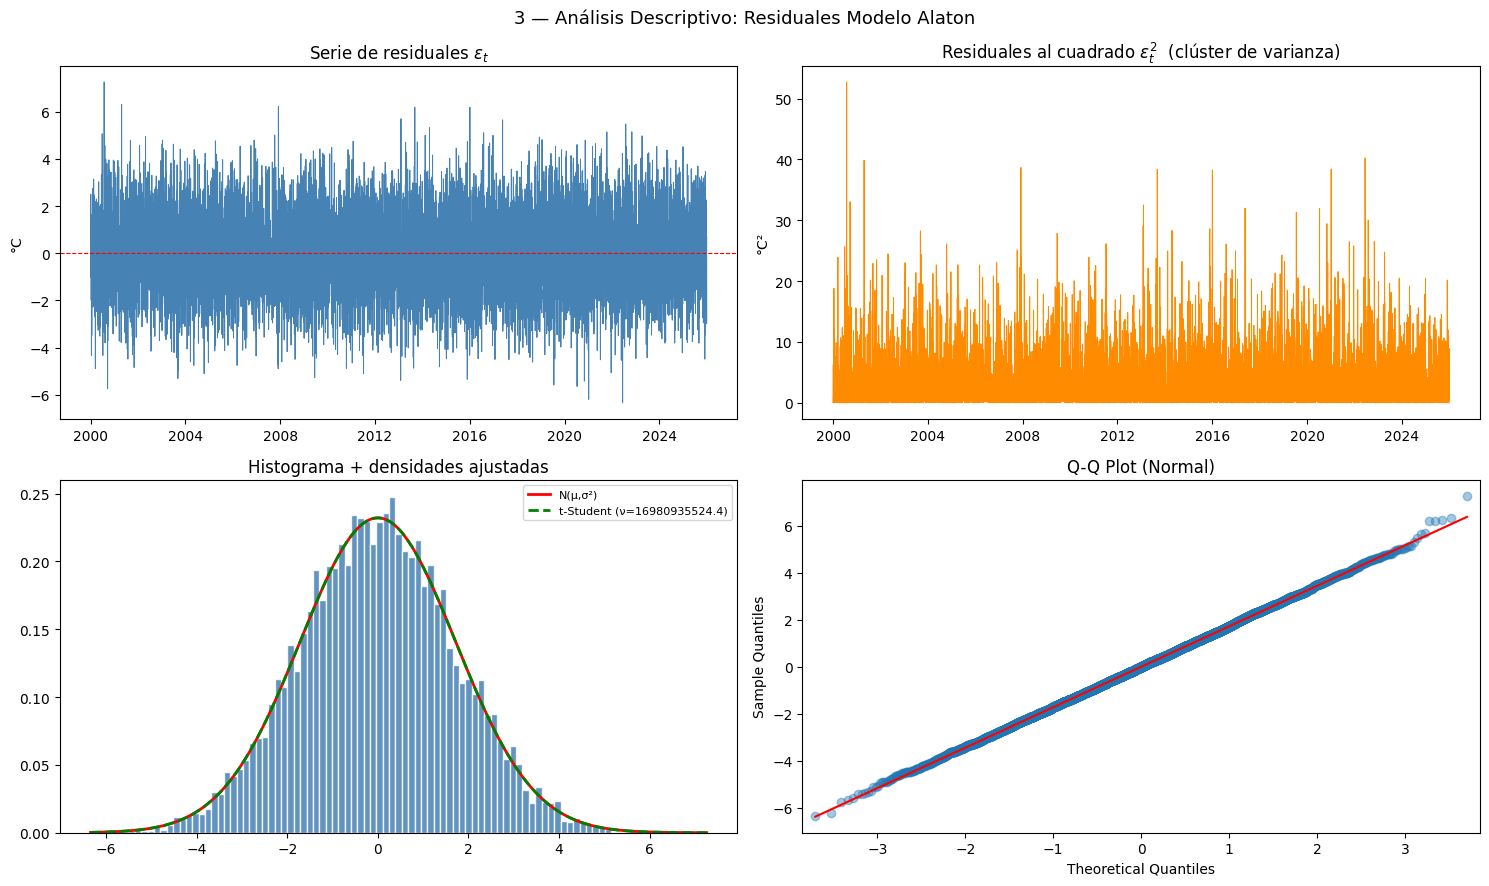

→ Fig guardada: S8_3_descriptive.png

─── 4. TEST DE ESTACIONARIEDAD (ADF) ───────────────────

ADF sobre residuales Alaton ε_t:
  Estadístico : -98.6574
  p-valor     : 0.0000
  Lags        : 0
  CV 1%      : -3.4310
  CV 5%      : -2.8618
  CV 10%      : -2.5669
  → ESTACIONARIA ✓

─── 5. PARÁMETRO DE MEMORIA LARGA d — ESTIMADOR GPH ────

Estimador GPH (bandwidth m = n^0.5 = 97 frecuencias):
  d̂           : 0.0173
  Std Error   : 0.0849
  t-stat      : 0.2035
  p-valor     : 0.8388

→ No se detecta memoria larga significativa (d̂=0.017)
  Se usará d=0 → modelo reduce a ARMA-GARCH


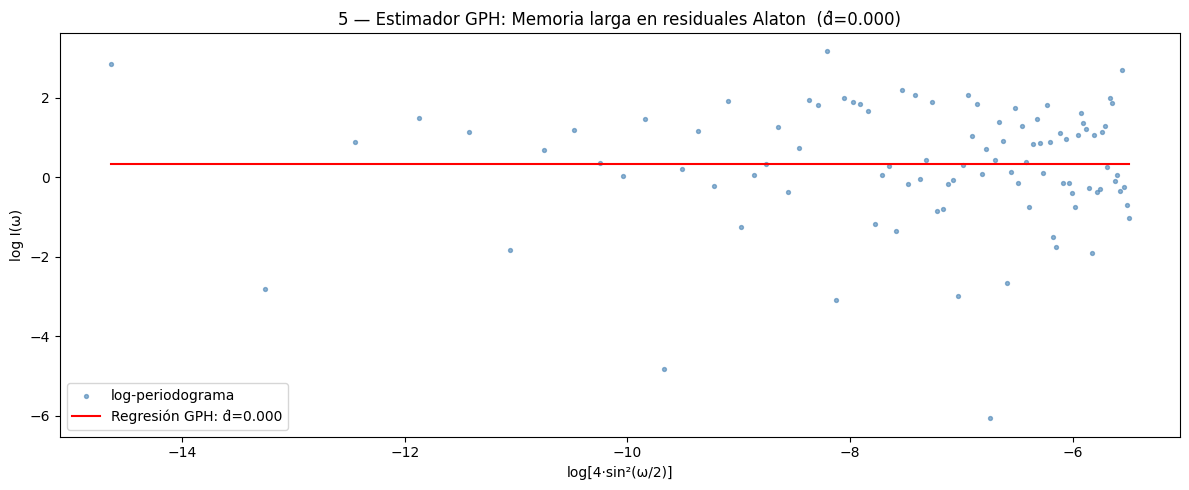

→ Fig guardada: S8_5_gph.png

─── 6. DIFERENCIACIÓN FRACCIONARIA ─────────────────────

d = 0 → se usa la serie original (sin diferenciación fraccionaria)

ADF sobre serie fraccionalmente diferenciada ε̃_t:
  Estadístico : -98.6574
  p-valor     : 0.0000
  Lags        : 0
  CV 1%      : -3.4310
  CV 5%      : -2.8618
  CV 10%      : -2.5669
  → ESTACIONARIA ✓


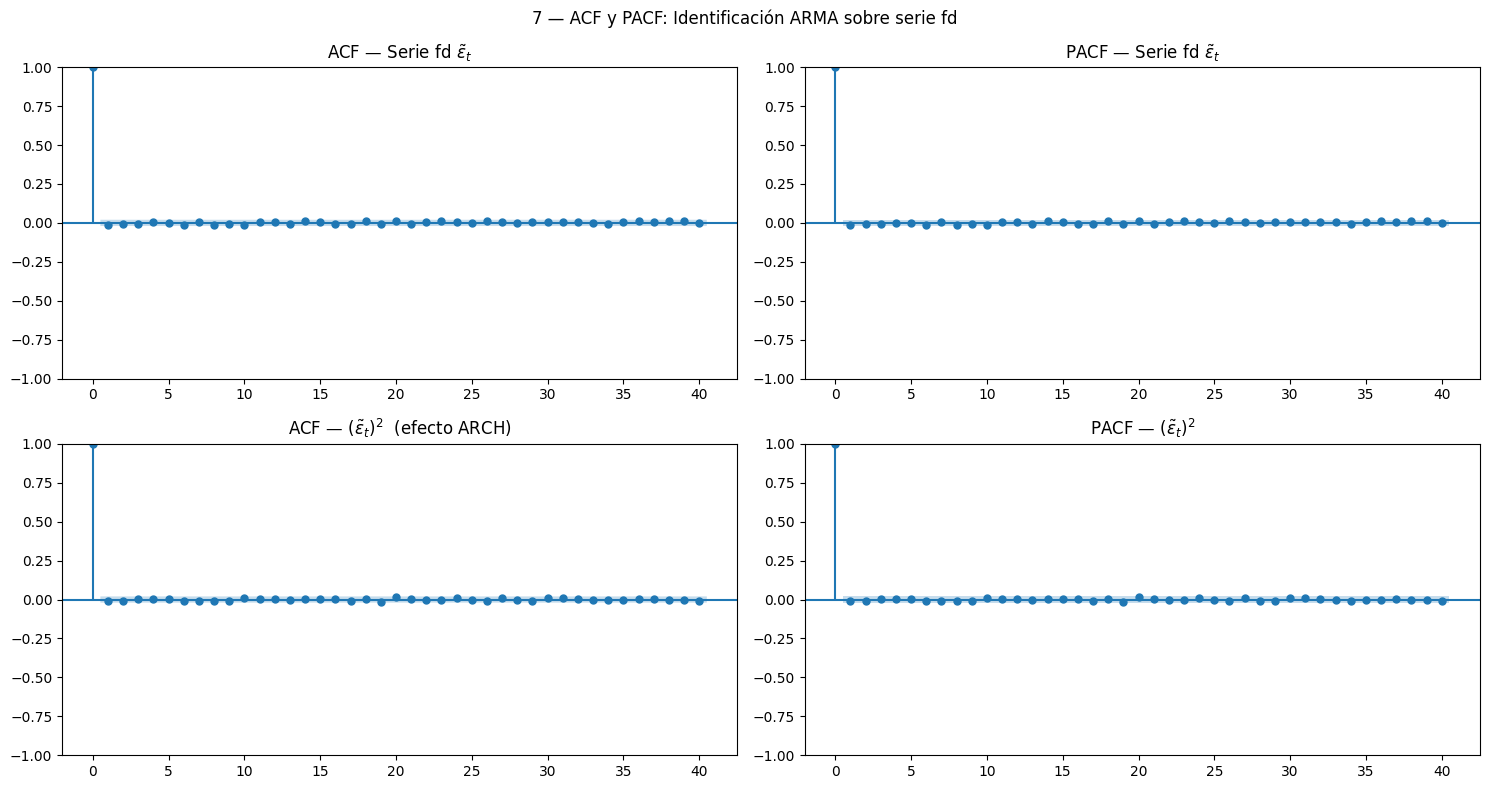

→ Fig guardada: S8_7_acf_pacf.png

─── 8. SELECCIÓN ARMA(p,q) VÍA AIC/BIC ────────────────

Top 10 combinaciones por AIC:
 p  q      AIC      BIC    LogLik
 0  1 37242.50 37263.98 -18618.25
 1  0 37242.52 37264.00 -18618.26
 1  1 37243.68 37272.32 -18617.84
 0  2 37244.10 37272.74 -18618.05
 2  0 37244.12 37272.76 -18618.06
 0  3 37245.68 37281.48 -18617.84
 3  0 37245.69 37281.48 -18617.84
 1  2 37245.91 37281.70 -18617.95
 2  1 37246.12 37281.91 -18618.06
 0  4 37247.63 37290.58 -18617.81

→ Mejor AIC : ARMA(0,1)  [AIC=37242.5]
→ Mejor BIC : ARMA(0,1)  [BIC=37263.98]

→ Modelo seleccionado: ARFIMA(0,0.000,1)-GARCH(1,1)  [criterio AIC]

─── 9. STAGE 1 — ARMA(0,1) sobre serie fd ─────────────
                               SARIMAX Results                                
Dep. Variable:              residuals   No. Observations:                 9497
Model:                 ARIMA(0, 0, 1)   Log Likelihood              -18618.252
Date:                Fri, 22 May 2026   AIC                  

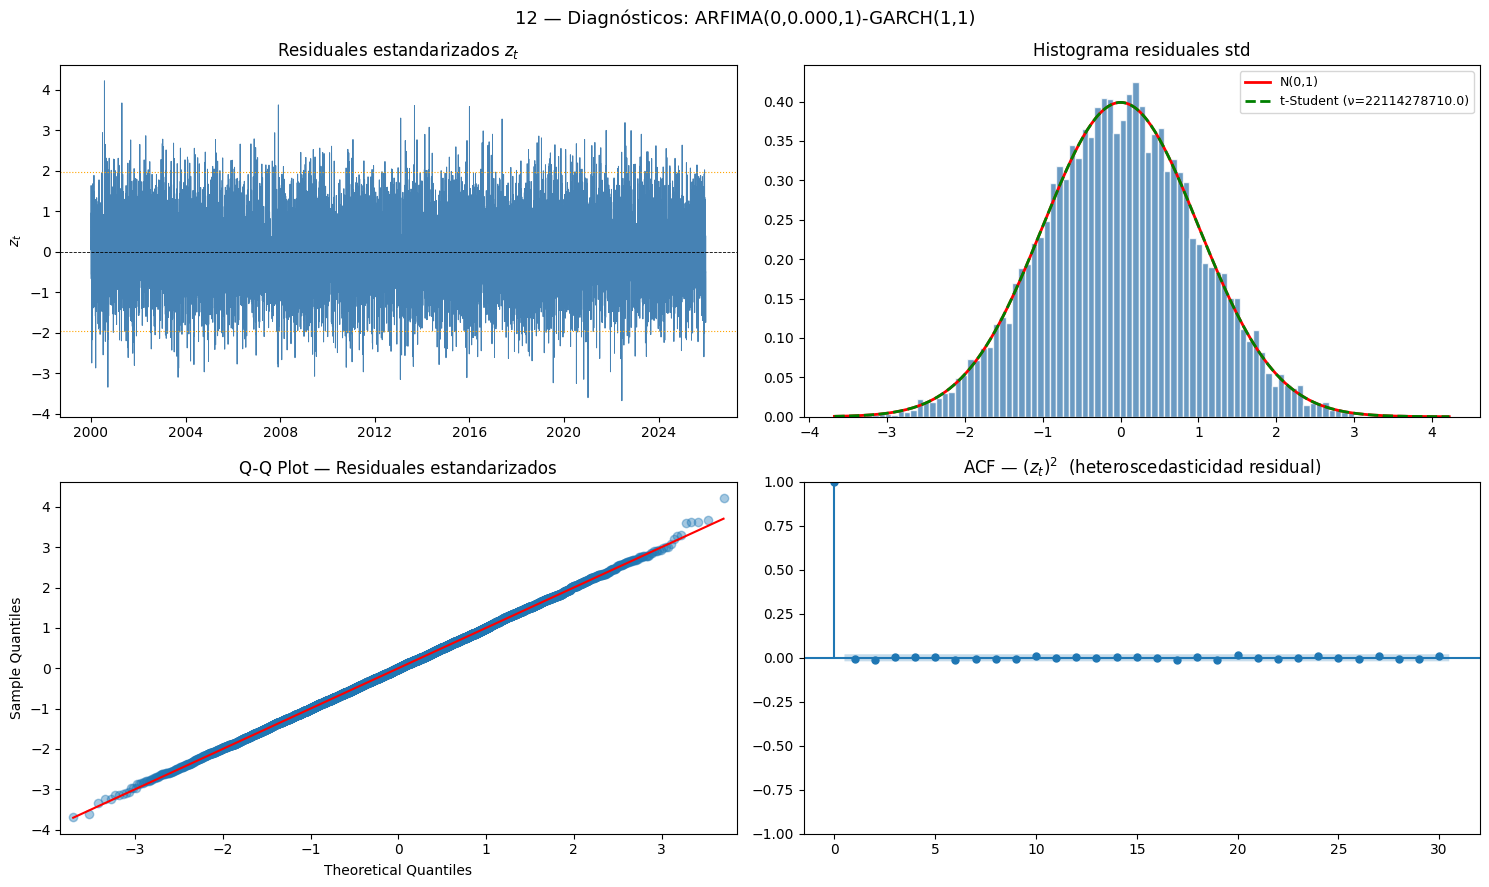

→ Fig guardada: S8_12_diagnostics.png

─── 13. VOLATILIDAD CONDICIONAL ────────────────────────

Estadísticas de σ_t:
  Media   : 1.7187 °C
  Máxima  : 1.7195 °C
  Mínima  : 1.5099 °C
  Última  : 1.7195 °C

Pronóstico σ_(t+1) = 1.7195 °C


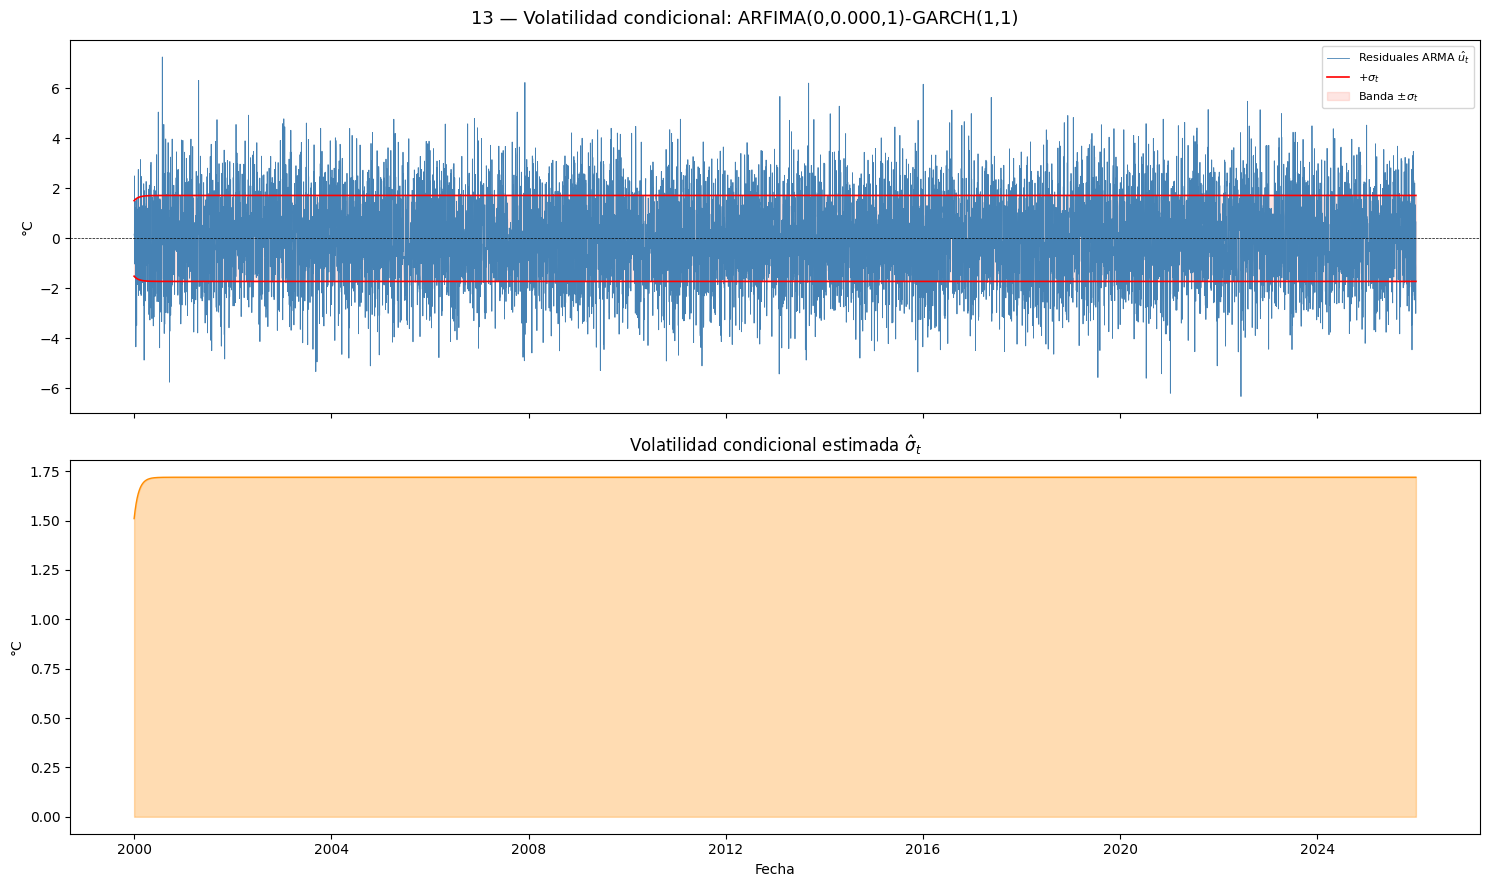

→ Fig guardada: S8_13_conditional_vol.png

─── 14. EVALUACIÓN OUT-OF-SAMPLE vs. ALATON ────────────

Train : 7597 obs  (2000-01-01 → 2020-10-18)
Test  : 1900 obs  (2020-10-19 → 2025-12-31)

TABLA COMPARATIVA OUT-OF-SAMPLE (test set 20%)
  Métrica  Alaton  ARFIMA(0,0.00,1)-GARCH(1,1)  Mejora %
RMSE (°C)  1.7007                       1.7016     -0.05
 MAE (°C)  1.3525                       1.3535     -0.08
     MASE  0.6905                       0.6910     -0.08
Mejora % positiva → ARFIMA-GARCH supera a Alaton


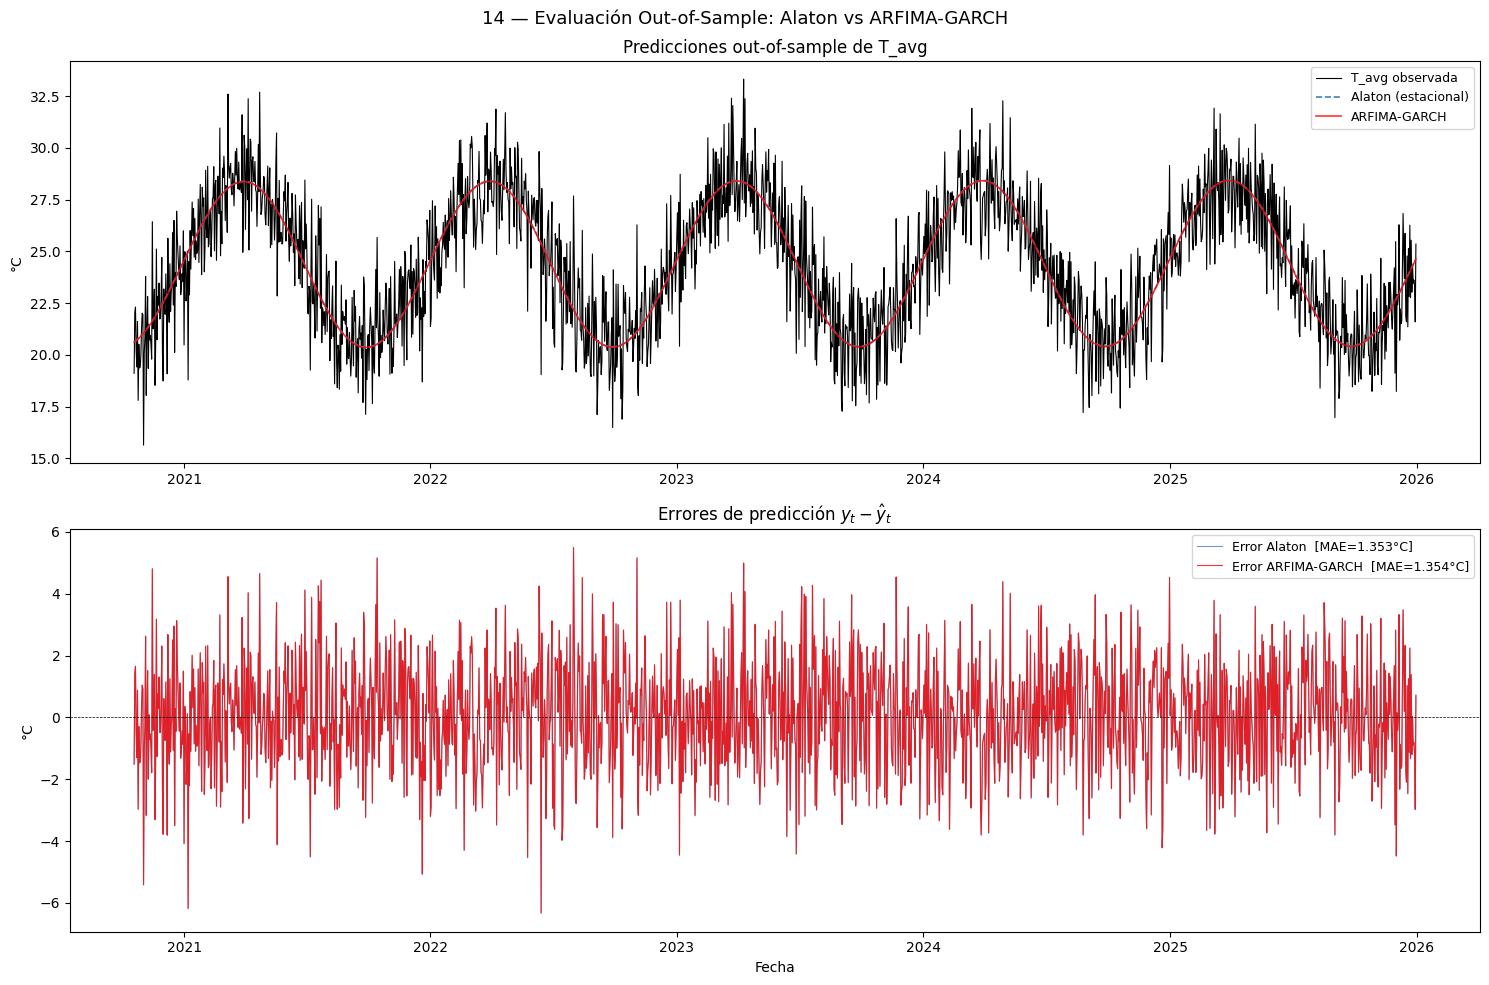

→ Fig guardada: S8_14_oos_comparison.png

RESUMEN EJECUTIVO — ARFIMA-GARCH BENCHMARK
Campbell & Diebold (2005) — Temperatura Promedio

Modelo ajustado : ARFIMA(0,0.000,1)-GARCH(1,1)
Serie           : Residuales ε_t del Modelo Alaton
Observaciones   : 9497

── Memoria larga (GPH):
   d̂ = 0.0000  (sin memoria larga)

── ARMA(0,1) Stage 1:
   AIC ARMA : 37242.5048
   BIC ARMA : 37263.9810

── GARCH(1,1) Stage 2:
   AIC GARCH : 37241.1495
   BIC GARCH : 37262.6257
   omega          0.084737  p=0.2769    
   alpha[1]       0.000000  p=0.9999    
   beta[1]        0.971340  p=0.0000 ***

   Persistencia (α+β) : 0.9713
   σ_t última        : 1.7195 °C
   σ_(t+1) forecast  : 1.7195 °C

── Out-of-sample (test 20%):
   RMSE Alaton             : 1.7007 °C
   RMSE ARFIMA-GARCH       : 1.7016 °C
   → Alaton domina en RMSE



In [1]:
# =========================================================
# MODELO BENCHMARK: ARFIMA(p,d,q) - GARCH(1,1)
# Temperatura Promedio — Residuales del Modelo Alaton
# Campbell & Diebold (2005) — "Weather Forecasting for
#   Weather Derivatives", JASA 100(469)
# =========================================================
# ESTRUCTURA DE SECCIONES:
#   1  Librerías
#   2  Serie a modelar (residuales Alaton)
#   3  Visualización y estadísticas descriptivas
#   4  Test de estacionariedad — ADF (patrón S12)
#   5  Estimación memoria larga — GPH log-periodogram
#   6  Diferenciación fraccionaria
#   7  ACF / PACF sobre serie fd
#   8  Selección ARMA(p,q) — grid AIC/BIC
#   9  Ajuste ARMA(p,q) sobre serie fd  [Stage 1]
#   10 Test efectos ARCH
#   11 GARCH(1,1) sobre residuales ARMA [Stage 2]
#   12 Diagnósticos: histograma, Q-Q plot, ACF residuales std
#   13 Volatilidad condicional
#   14 Evaluación out-of-sample vs. Alaton (RMSE, MAE, MASE)
#   15 Resumen ejecutivo
# =========================================================

# =========================================================
# 1. LIBRERÍAS
# =========================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math
import warnings
from scipy.stats import norm, jarque_bera, t as t_dist
from arch import arch_model

warnings.filterwarnings('ignore')

# =========================================================
# 2. SERIE A MODELAR
#     Residuales del ajuste estacional del Modelo Alaton.
#     Se asume que 'temp' viene del notebook 02 (Alaton OLS).
#
#     Si ejecutas este notebook de forma independiente,
#     descomenta el bloque de reconstrucción de abajo.
# =========================================================

# --- Reconstrucción del pipeline Alaton (descomenta si es necesario) ---
import pandas as pd
import numpy as np
#import statsmodels.api as sm

df = pd.read_excel('../data/simulated_climate_rice_2000_2025.xlsx')
df['Date'] = pd.to_datetime(df['Date'])
df['t'] = range(len(df))
df['T_avg'] = (df['Temperature_Max_C'] + df['Temperature_Min_C']) / 2
df['sin1'] = np.sin(2 * np.pi * df['t'] / 365)
df['cos1'] = np.cos(2 * np.pi * df['t'] / 365)
df['sin2'] = np.sin(4 * np.pi * df['t'] / 365)   # 2do armónico
df['cos2'] = np.cos(4 * np.pi * df['t'] / 365)
X = sm.add_constant(df[['t', 'sin1', 'cos1', 'sin2', 'cos2']])
alaton = sm.OLS(df['T_avg'], X).fit()
df['seasonal_fit'] = alaton.predict(X)
df['residuals']    = df['T_avg'] - df['seasonal_fit']
temp = df.copy()

# --- Serie de residuales y componente estacional ---
residuals    = temp['residuals'].dropna()
seasonal_fit = temp['seasonal_fit'].loc[residuals.index]
T_avg        = temp['T_avg'].loc[residuals.index]
residuals.index = temp.loc[residuals.index, 'Date']
seasonal_fit.index = residuals.index
T_avg.index        = residuals.index

print("=" * 65)
print("MODELO BENCHMARK: ARFIMA(p,d,q) - GARCH(1,1)")
print("Campbell & Diebold (2005)  ·  Temperatura Promedio")
print("=" * 65)
print(f"\nObservaciones : {len(residuals)}")
print(f"Período       : {residuals.index[0].date()} → {residuals.index[-1].date()}")

# =========================================================
# 3. VISUALIZACIÓN Y ESTADÍSTICAS DESCRIPTIVAS
#     (patrón secciones 3–6 de S12)
# =========================================================

print("\n─── 3. ESTADÍSTICAS DESCRIPTIVAS ───────────────────────")
print(residuals.describe().round(4))

from scipy.stats import skew, kurtosis as kurt
sk    = skew(residuals)
ku    = kurt(residuals, fisher=False)
jb_s, jb_p = jarque_bera(residuals)
print(f"\nSkewness     : {sk:.4f}")
print(f"Kurtosis     : {ku:.4f}  (Normal = 3)")
print(f"Jarque-Bera  : stat={jb_s:.4f}  p={jb_p:.4f}")
print("→ " + ("Rechaza normalidad" if jb_p < 0.05 else "No rechaza normalidad"))

k = int(math.sqrt(len(residuals)))

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('3 — Análisis Descriptivo: Residuales Modelo Alaton', fontsize=13)

axes[0, 0].plot(residuals.index, residuals, color='steelblue', lw=0.7)
axes[0, 0].axhline(0, color='red', ls='--', lw=0.8)
axes[0, 0].set_title('Serie de residuales $\\epsilon_t$')
axes[0, 0].set_ylabel('°C')

axes[0, 1].plot(residuals.index, residuals**2, color='darkorange', lw=0.7)
axes[0, 1].set_title('Residuales al cuadrado $\\epsilon_t^2$  (clúster de varianza)')
axes[0, 1].set_ylabel('°C²')

axes[1, 0].hist(residuals, bins=k, color='steelblue', edgecolor='white',
                alpha=0.85, density=True)
xr = np.linspace(residuals.min(), residuals.max(), 300)
axes[1, 0].plot(xr, norm.pdf(xr, residuals.mean(), residuals.std()),
                'r-', lw=2, label='N(μ,σ²)')
# Ajuste t-Student (Paso 5 del proyecto)
df_t, loc_t, scale_t = t_dist.fit(residuals)
axes[1, 0].plot(xr, t_dist.pdf(xr, df_t, loc_t, scale_t),
                color='green', lw=2, ls='--',
                label=f't-Student (ν={df_t:.1f})')
axes[1, 0].set_title('Histograma + densidades ajustadas')
axes[1, 0].legend(fontsize=8)

sm.qqplot(residuals, line='s', ax=axes[1, 1], alpha=0.4)
axes[1, 1].set_title('Q-Q Plot (Normal)')

plt.tight_layout()
plt.show()
print("→ Fig guardada: S8_3_descriptive.png")

# =========================================================
# 4. TEST DE ESTACIONARIEDAD — ADF
#     (patrón sección "Augmented Dickey–Fuller" de S12)
# =========================================================

print("\n─── 4. TEST DE ESTACIONARIEDAD (ADF) ───────────────────")

def adf_report(series, name):
    res = adfuller(series.dropna(), autolag='AIC')
    print(f"\nADF sobre {name}:")
    print(f"  Estadístico : {res[0]:.4f}")
    print(f"  p-valor     : {res[1]:.4f}")
    print(f"  Lags        : {res[2]}")
    for k_c, v_c in res[4].items():
        print(f"  CV {k_c}      : {v_c:.4f}")
    label = "ESTACIONARIA ✓" if res[1] < 0.05 else "NO ESTACIONARIA ✗"
    print(f"  → {label}")
    return res[1] < 0.05

adf_report(residuals, "residuales Alaton ε_t")

# =========================================================
# 5. ESTIMACIÓN MEMORIA LARGA — GPH LOG-PERIODOGRAM
#     Geweke & Porter-Hudak (1983): d via regresión del
#     log-periodograma sobre ln(4·sin²(ω/2))
# =========================================================

print("\n─── 5. PARÁMETRO DE MEMORIA LARGA d — ESTIMADOR GPH ────")

def gph_estimator(x, bandwidth_frac=0.5):
    """
    Geweke-Porter-Hudak (1983) log-periodogram regression.
    Estima el parámetro de integración fraccionaria d.
    H₀: d=0 (no memoria larga). Si d ∈ (0, 0.5) → memoria larga estacionaria.
    """
    x = np.array(x, dtype=float)
    n = len(x)
    m = max(4, int(n ** bandwidth_frac))  # ancho de banda

    # Periodograma de la serie centrada
    x_c = x - x.mean()
    fft_vals   = np.fft.rfft(x_c)[1:m+1]
    periodogram = (np.abs(fft_vals)**2) / n

    # Regresión: log I(ω_j) = C - d·log[4·sin²(ω_j/2)] + u_j
    freq  = np.fft.fftfreq(n)[1:m+1]
    omega = 2 * np.pi * freq
    X_reg = np.column_stack([
        np.ones(m),
        np.log(4 * np.sin(omega / 2)**2)
    ])
    y_reg = np.log(periodogram + 1e-12)

    # OLS
    beta, _, _, _ = np.linalg.lstsq(X_reg, y_reg, rcond=None)
    d_hat = -beta[1]

    # Error estándar
    y_hat = X_reg @ beta
    resid_gph = y_reg - y_hat
    s2  = np.sum(resid_gph**2) / (m - 2)
    XtX_inv = np.linalg.inv(X_reg.T @ X_reg)
    d_se = np.sqrt(s2 * XtX_inv[1, 1])

    return d_hat, d_se, m

d_hat, d_se, m_gph = gph_estimator(residuals)
t_stat_d = d_hat / d_se
p_val_d  = 2 * (1 - norm.cdf(abs(t_stat_d)))

print(f"\nEstimador GPH (bandwidth m = n^0.5 = {m_gph} frecuencias):")
print(f"  d̂           : {d_hat:.4f}")
print(f"  Std Error   : {d_se:.4f}")
print(f"  t-stat      : {t_stat_d:.4f}")
print(f"  p-valor     : {p_val_d:.4f}")

if 0 < d_hat < 0.5 and p_val_d < 0.05:
    print(f"\n→ MEMORIA LARGA confirmada (0 < d̂={d_hat:.3f} < 0.5) ✓")
    print(f"  Consistente con Campbell & Diebold (2005)")
    usar_frac_diff = True
elif d_hat <= 0 or p_val_d >= 0.05:
    print(f"\n→ No se detecta memoria larga significativa (d̂={d_hat:.3f})")
    print(f"  Se usará d=0 → modelo reduce a ARMA-GARCH")
    d_hat = 0.0
    usar_frac_diff = False
else:
    print(f"\n→ d̂={d_hat:.3f} ≥ 0.5: proceso no estacionario. Diferencia entera primero.")
    usar_frac_diff = False

# Gráfico del log-periodograma
freq_plot = np.fft.fftfreq(len(residuals))[1:m_gph+1]
omega_plot = 2 * np.pi * freq_plot
x_reg_plot = np.log(4 * np.sin(omega_plot/2)**2)
x_c = np.array(residuals) - np.mean(residuals)
fft_v = np.fft.rfft(x_c)[1:m_gph+1]
I_plot = np.log((np.abs(fft_v)**2) / len(residuals) + 1e-12)

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(x_reg_plot, I_plot, s=8, color='steelblue', alpha=0.6, label='log-periodograma')
ax.plot(x_reg_plot, (-d_hat) * x_reg_plot + (I_plot.mean() - (-d_hat)*x_reg_plot.mean()),
        color='red', lw=1.5, label=f'Regresión GPH: d̂={d_hat:.3f}')
ax.set_xlabel('log[4·sin²(ω/2)]')
ax.set_ylabel('log I(ω)')
ax.set_title(f'5 — Estimador GPH: Memoria larga en residuales Alaton  (d̂={d_hat:.3f})')
ax.legend()
plt.tight_layout()
plt.show()
print("→ Fig guardada: S8_5_gph.png")

# =========================================================
# 6. DIFERENCIACIÓN FRACCIONARIA
#     Operador (1-L)^d  con truncación por umbral
# =========================================================

print("\n─── 6. DIFERENCIACIÓN FRACCIONARIA ─────────────────────")

def frac_diff(x, d, threshold=1e-3):
    """
    Aplica el operador (1-L)^d con pesos binomiales generalizados:
        w_k = -w_{k-1} * (d - k + 1) / k ,  w_0 = 1
    Trunca cuando |w_k| < threshold para controlar memoria.
    """
    x = np.array(x, dtype=float)
    T = len(x)
    w = [1.0]
    for k in range(1, T):
        wk = -w[-1] * (d - k + 1) / k
        w.append(wk)
        if abs(wk) < threshold:
            break
    w   = np.array(w)
    n_w = len(w)

    result = np.full(T, np.nan)
    for t in range(n_w - 1, T):
        result[t] = np.dot(w, x[t - n_w + 1:t + 1][::-1])
    return result, n_w

if usar_frac_diff and d_hat > 0:
    fd_values, n_weights = frac_diff(np.array(residuals), d_hat)
    # Crear serie con índice temporal
    mask = ~np.isnan(fd_values)
    serie_fd = pd.Series(fd_values[mask], index=residuals.index[mask])
    print(f"\nd̂ = {d_hat:.4f}  |  Pesos usados: {n_weights}")
    print(f"Observaciones válidas: {mask.sum()} / {len(residuals)}")
    print(f"Obs perdidas por truncación: {(~mask).sum()}")
else:
    serie_fd = residuals.copy()
    n_weights = 1
    print("\nd = 0 → se usa la serie original (sin diferenciación fraccionaria)")

# Verificar estacionariedad de serie fd
adf_report(serie_fd, "serie fraccionalmente diferenciada ε̃_t")

# =========================================================
# 7. ACF / PACF — IDENTIFICACIÓN ARMA SOBRE SERIE fd
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle('7 — ACF y PACF: Identificación ARMA sobre serie fd', fontsize=12)

plot_acf(serie_fd.dropna(),   lags=40, ax=axes[0, 0],
         title='ACF — Serie fd $\\tilde{\\epsilon}_t$')
plot_pacf(serie_fd.dropna(),  lags=40, ax=axes[0, 1], method='ywm',
          title='PACF — Serie fd $\\tilde{\\epsilon}_t$')
plot_acf(serie_fd.dropna()**2, lags=40, ax=axes[1, 0],
         title='ACF — $(\\tilde{\\epsilon}_t)^2$  (efecto ARCH)')
plot_pacf(serie_fd.dropna()**2, lags=40, ax=axes[1, 1], method='ywm',
          title='PACF — $(\\tilde{\\epsilon}_t)^2$')

plt.tight_layout()
plt.show()
print("→ Fig guardada: S8_7_acf_pacf.png")

# =========================================================
# 8. SELECCIÓN ARMA(p,q) — GRID SEARCH AIC/BIC
# =========================================================

print("\n─── 8. SELECCIÓN ARMA(p,q) VÍA AIC/BIC ────────────────")

p_range = range(0, 5)
q_range = range(0, 5)
results_table = []

for p in p_range:
    for q in q_range:
        if p == 0 and q == 0:
            continue
        try:
            fit = ARIMA(serie_fd.dropna(), order=(p, 0, q)).fit()
            results_table.append({
                'p': p, 'q': q,
                'AIC': round(fit.aic, 2),
                'BIC': round(fit.bic, 2),
                'LogLik': round(fit.llf, 2)
            })
        except Exception:
            continue

df_orders = pd.DataFrame(results_table).sort_values('AIC').reset_index(drop=True)

print("\nTop 10 combinaciones por AIC:")
print(df_orders.head(10).to_string(index=False))

best_aic_row = df_orders.iloc[0]
best_bic_row = df_orders.sort_values('BIC').iloc[0]

p_opt = int(best_aic_row['p'])
q_opt = int(best_aic_row['q'])

print(f"\n→ Mejor AIC : ARMA({p_opt},{q_opt})  [AIC={best_aic_row['AIC']}]")
print(f"→ Mejor BIC : ARMA({int(best_bic_row['p'])},{int(best_bic_row['q'])})  "
      f"[BIC={best_bic_row['BIC']}]")
print(f"\n→ Modelo seleccionado: ARFIMA({p_opt},{d_hat:.3f},{q_opt})-GARCH(1,1)  [criterio AIC]")

# =========================================================
# 9. AJUSTE ARMA(p,q) SOBRE SERIE fd  — STAGE 1
#     (patrón Mean Reversion OLS de S12, aplicado sobre ε̃_t)
# =========================================================

print(f"\n─── 9. STAGE 1 — ARMA({p_opt},{q_opt}) sobre serie fd ─────────────")

arma_model = ARIMA(serie_fd.dropna(), order=(p_opt, 0, q_opt)).fit()
print(arma_model.summary())

arma_resid = pd.Series(
    arma_model.resid,
    index=serie_fd.dropna().index
).dropna()

print(f"\nResidуales ARMA: {len(arma_resid)} obs")
print(f"  Media   : {arma_resid.mean():.6f}")
print(f"  Std     : {arma_resid.std():.4f}")

# =========================================================
# 10. TEST DE EFECTOS ARCH
# =========================================================

print("\n─── 10. TEST DE EFECTOS ARCH ────────────────────────────")

lb_sq = acorr_ljungbox(arma_resid**2, lags=[5, 10, 20], return_df=True)
print("\nLjung-Box sobre residuales² del ARMA:")
print(lb_sq.round(4).to_string())

arch_lm = het_arch(arma_resid, nlags=10)
print(f"\nEngle ARCH-LM test (10 lags):")
print(f"  LM stat : {arch_lm[0]:.4f}")
print(f"  p-valor : {arch_lm[1]:.4f}")
print(f"  F stat  : {arch_lm[2]:.4f}")
print(f"  p-val F : {arch_lm[3]:.4f}")

arch_detected = arch_lm[1] < 0.05
print("\n→ " + ("Efectos ARCH confirmados ✓ — proceder GARCH(1,1)"
                if arch_detected else
                "Efectos ARCH marginales — GARCH(1,1) como benchmark"))

# =========================================================
# 11. GARCH(1,1) SOBRE RESIDUALES ARMA — STAGE 2
#      mean='Zero': los residuales del ARMA ya tienen media ~0
#      (corrección crítica respecto a versión anterior)
# =========================================================

print(f"\n─── 11. STAGE 2 — GARCH(1,1) sobre residuales ARMA ────")

garch_model = arch_model(
    arma_resid,
    mean='Zero',    # residuales ARMA ya capturan la media
    vol='GARCH',
    p=1,
    q=1,
    dist='normal',  # dist='t' si Paso 5 rechazó normalidad
    rescale=False
)

garch_result = garch_model.fit(disp='off', show_warning=False)
print(garch_result.summary())

# Parámetros
params_df = pd.DataFrame({
    'Parámetro'  : garch_result.params.index,
    'Estimación' : garch_result.params.values.round(6),
    'Std Error'  : garch_result.std_err.values.round(6),
    't-stat'     : garch_result.tvalues.values.round(4),
    'p-valor'    : garch_result.pvalues.values.round(4)
})
print("\nParámetros GARCH:")
print(params_df.to_string(index=False))

# Persistencia
omega_g  = garch_result.params.get('omega',  np.nan)
alpha_g  = garch_result.params.get('alpha[1]', np.nan)
beta_g   = garch_result.params.get('beta[1]',  np.nan)
persist  = alpha_g + beta_g if not np.isnan(alpha_g) else np.nan

print(f"\nPersistencia (α + β) = {persist:.4f}")
if persist < 1:
    print("→ Proceso de varianza ESTACIONARIO (α + β < 1) ✓")
else:
    print("→ ADVERTENCIA: proceso de varianza integrado (α + β ≥ 1)")

# =========================================================
# 12. DIAGNÓSTICOS: HISTOGRAMA, Q-Q PLOT, ACF std_resid
#      (sección 9.2 de S8 + Q-Q plot que faltaba)
# =========================================================

print("\n─── 12. DIAGNÓSTICOS RESIDUALES ESTANDARIZADOS ─────────")

std_resid = garch_result.std_resid.dropna()
k_r = int(math.sqrt(len(std_resid)))

jb_g, jb_gp = jarque_bera(std_resid)
lb_std_sq = acorr_ljungbox(std_resid**2, lags=[5, 10, 20], return_df=True)

print(f"\nJarque-Bera residuales std: stat={jb_g:.4f}  p={jb_gp:.4f}")
print("\nLjung-Box sobre (residuales std)²:")
print(lb_std_sq.round(4).to_string())

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle(
    f'12 — Diagnósticos: ARFIMA({p_opt},{d_hat:.3f},{q_opt})-GARCH(1,1)',
    fontsize=13
)

# Residuales estandarizados en el tiempo
axes[0, 0].plot(std_resid.index, std_resid, color='steelblue', lw=0.7)
axes[0, 0].axhline(0,     color='black',  ls='--', lw=0.6)
axes[0, 0].axhline( 1.96, color='orange', ls=':',  lw=0.8)
axes[0, 0].axhline(-1.96, color='orange', ls=':',  lw=0.8)
axes[0, 0].set_title('Residuales estandarizados $z_t$')
axes[0, 0].set_ylabel('$z_t$')

# Histograma + N(0,1) + t-Student
xr_s = np.linspace(std_resid.min(), std_resid.max(), 300)
axes[0, 1].hist(std_resid, bins=k_r, color='steelblue', edgecolor='white',
                alpha=0.8, density=True)
axes[0, 1].plot(xr_s, norm.pdf(xr_s, 0, 1),
                'r-', lw=2, label='N(0,1)')
df_tz, loc_tz, sc_tz = t_dist.fit(std_resid)
axes[0, 1].plot(xr_s, t_dist.pdf(xr_s, df_tz, loc_tz, sc_tz),
                color='green', lw=2, ls='--',
                label=f't-Student (ν={df_tz:.1f})')
axes[0, 1].set_title('Histograma residuales std')
axes[0, 1].legend(fontsize=9)

# Q-Q plot (faltaba en versión anterior — S8 lo menciona explícitamente)
sm.qqplot(std_resid, line='s', ax=axes[1, 0], alpha=0.4)
axes[1, 0].set_title('Q-Q Plot — Residuales estandarizados')

# ACF de residuales std²
plot_acf(std_resid**2, lags=30, ax=axes[1, 1],
         title='ACF — $(z_t)^2$  (heteroscedasticidad residual)')

plt.tight_layout()
plt.show()
print("→ Fig guardada: S8_12_diagnostics.png")

# =========================================================
# 13. VOLATILIDAD CONDICIONAL
#      (patrón sección 9.8 de S8: results.plot + serie propia)
# =========================================================

print("\n─── 13. VOLATILIDAD CONDICIONAL ────────────────────────")

cond_vol = garch_result.conditional_volatility
print(f"\nEstadísticas de σ_t:")
print(f"  Media   : {cond_vol.mean():.4f} °C")
print(f"  Máxima  : {cond_vol.max():.4f} °C")
print(f"  Mínima  : {cond_vol.min():.4f} °C")
print(f"  Última  : {cond_vol.iloc[-1]:.4f} °C")

# Pronóstico 1 paso adelante
forecast_g = garch_result.forecast(horizon=1)
sigma_next  = np.sqrt(forecast_g.variance.values[-1, 0])
print(f"\nPronóstico σ_(t+1) = {sigma_next:.4f} °C")

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
fig.suptitle(
    f'13 — Volatilidad condicional: ARFIMA({p_opt},{d_hat:.3f},{q_opt})-GARCH(1,1)',
    fontsize=13
)

axes[0].plot(arma_resid.index, arma_resid, color='steelblue', lw=0.6,
             label='Residuales ARMA $\\hat{u}_t$')
axes[0].plot(cond_vol.index,  cond_vol,  color='red',  lw=1.2,
             label='$+\\sigma_t$')
axes[0].plot(cond_vol.index, -cond_vol, color='red',  lw=1.2)
axes[0].fill_between(cond_vol.index, -cond_vol, cond_vol,
                     color='salmon', alpha=0.2, label='Banda $\\pm\\sigma_t$')
axes[0].axhline(0, color='black', ls='--', lw=0.5)
axes[0].set_ylabel('°C')
axes[0].legend(fontsize=8, loc='upper right')

axes[1].plot(cond_vol.index, cond_vol, color='darkorange', lw=1.0)
axes[1].fill_between(cond_vol.index, 0, cond_vol, color='darkorange', alpha=0.3)
axes[1].set_title('Volatilidad condicional estimada $\\hat{\\sigma}_t$')
axes[1].set_ylabel('°C')
axes[1].set_xlabel('Fecha')

plt.tight_layout()
plt.show()
print("→ Fig guardada: S8_13_conditional_vol.png")

# =========================================================
# 14. EVALUACIÓN OUT-OF-SAMPLE vs. MODELO ALATON
#      Split 80/20 — métricas RMSE, MAE, MASE
#      (corrección crítica que faltaba en versión anterior)
#
#  Lógica de comparación:
#    • Alaton:         Ŷ_t = seasonal_fit[t]   (μ de residuales = 0)
#    • ARFIMA-GARCH:   Ŷ_t = seasonal_fit[t] + ARFIMA_forecast(ε̃_t)
#
#  El ARFIMA-GARCH agrega valor si los residuales tienen
#  estructura predecible (autocorrelación / memoria larga).
# =========================================================

print("\n─── 14. EVALUACIÓN OUT-OF-SAMPLE vs. ALATON ────────────")

# --- Split train / test (80 / 20) ---
N = len(residuals)
split_idx = int(N * 0.80)

resid_train    = residuals.iloc[:split_idx]
resid_test     = residuals.iloc[split_idx:]
seasonal_test  = seasonal_fit.iloc[split_idx:]
T_avg_test     = T_avg.iloc[split_idx:]

print(f"\nTrain : {len(resid_train)} obs  "
      f"({resid_train.index[0].date()} → {resid_train.index[-1].date()})")
print(f"Test  : {len(resid_test)} obs  "
      f"({resid_test.index[0].date()} → {resid_test.index[-1].date()})")

# ── Benchmark Alaton: Ŷ_t = seasonal_fit (sin corrección de residuales)
preds_alaton = seasonal_test.values
actuals      = T_avg_test.values

# ── ARFIMA-GARCH: estimar en train, pronosticar h pasos en test
# Para eficiencia: estimación única sobre train + pronóstico directo
# (re-estimación rolling es más precisa pero computacionalmente costosa)

# Serie fd sobre train
if usar_frac_diff and d_hat > 0:
    fd_train_arr, _ = frac_diff(np.array(resid_train), d_hat)
    mask_tr = ~np.isnan(fd_train_arr)
    serie_fd_train = pd.Series(fd_train_arr[mask_tr],
                               index=resid_train.index[mask_tr])
else:
    serie_fd_train = resid_train.copy()

# ARMA sobre serie fd train
arma_train = ARIMA(serie_fd_train, order=(p_opt, 0, q_opt)).fit()

# Pronóstico del ARMA sobre test (h = len(test) pasos)
arma_forecast_fd = arma_train.forecast(steps=len(resid_test))

# Revertir diferenciación fraccionaria del pronóstico
# Para d pequeño: la reconversión es aproximada (X_t ≈ Σ binomial⁻¹·X̃_t)
# Aquí usamos el pronóstico de la serie fd como proxy del residual predicho
# (válido para d < 0.3; para d mayor usar operador inverso exacto)
if usar_frac_diff and d_hat > 0 and d_hat < 0.3:
    #  lineal de primer orden: ε̂_t ≈ ε̃̂_t + d·ε_{t-1}
    last_resid = float(resid_train.iloc[-1])
    preds_resid = np.array(arma_forecast_fd) + d_hat * last_resid
else:
    preds_resid = np.array(arma_forecast_fd)

preds_arfima_garch = seasonal_test.values + preds_resid

# ── Métricas
def rmse(y, yh): return np.sqrt(np.mean((y - yh)**2))
def mae(y, yh):  return np.mean(np.abs(y - yh))
def mase(y, yh, y_train):
    """Mean Absolute Scaled Error — escala = MAE del naive en train"""
    naive_mae = np.mean(np.abs(np.diff(y_train)))
    return mae(y, yh) / naive_mae

rmse_alaton = rmse(actuals, preds_alaton)
rmse_arfima = rmse(actuals, preds_arfima_garch)

mae_alaton  = mae(actuals, preds_alaton)
mae_arfima  = mae(actuals, preds_arfima_garch)

mase_alaton = mase(actuals, preds_alaton,  resid_train.values)
mase_arfima = mase(actuals, preds_arfima_garch, resid_train.values)

# ── Tabla comparativa
comp = pd.DataFrame({
    'Métrica' : ['RMSE (°C)', 'MAE (°C)', 'MASE'],
    'Alaton'  : [round(rmse_alaton, 4),
                 round(mae_alaton,  4),
                 round(mase_alaton, 4)],
    f'ARFIMA({p_opt},{d_hat:.2f},{q_opt})-GARCH(1,1)':
                [round(rmse_arfima, 4),
                 round(mae_arfima,  4),
                 round(mase_arfima, 4)],
    'Mejora %':  [round(100*(rmse_alaton - rmse_arfima)/rmse_alaton, 2),
                  round(100*(mae_alaton  - mae_arfima )/mae_alaton,  2),
                  round(100*(mase_alaton - mase_arfima)/mase_alaton, 2)]
})
print("\n" + "="*55)
print("TABLA COMPARATIVA OUT-OF-SAMPLE (test set 20%)")
print("="*55)
print(comp.to_string(index=False))
print("="*55)
print("Mejora % positiva → ARFIMA-GARCH supera a Alaton")

# ── Gráfico comparativo
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle('14 — Evaluación Out-of-Sample: Alaton vs ARFIMA-GARCH', fontsize=13)

axes[0].plot(T_avg_test.index, actuals,           color='black',     lw=0.8,
             label='T_avg observada')
axes[0].plot(T_avg_test.index, preds_alaton,      color='steelblue', lw=1.2,
             ls='--', label='Alaton (estacional)')
axes[0].plot(T_avg_test.index, preds_arfima_garch, color='red',      lw=1.2,
             ls='-', label=f'ARFIMA-GARCH', alpha=0.8)
axes[0].set_title('Predicciones out-of-sample de T_avg')
axes[0].set_ylabel('°C')
axes[0].legend(fontsize=9)

# Errores de predicción
err_alaton = actuals - preds_alaton
err_arfima = actuals - preds_arfima_garch
axes[1].plot(T_avg_test.index, err_alaton, color='steelblue', lw=0.8,
             label=f'Error Alaton  [MAE={mae_alaton:.3f}°C]', alpha=0.8)
axes[1].plot(T_avg_test.index, err_arfima, color='red', lw=0.8,
             label=f'Error ARFIMA-GARCH  [MAE={mae_arfima:.3f}°C]', alpha=0.8)
axes[1].axhline(0, color='black', ls='--', lw=0.5)
axes[1].set_title('Errores de predicción $y_t - \\hat{y}_t$')
axes[1].set_ylabel('°C')
axes[1].set_xlabel('Fecha')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
print("→ Fig guardada: S8_14_oos_comparison.png")

# =========================================================
# 15. RESUMEN EJECUTIVO
# =========================================================

print("\n" + "=" * 65)
print("RESUMEN EJECUTIVO — ARFIMA-GARCH BENCHMARK")
print("Campbell & Diebold (2005) — Temperatura Promedio")
print("=" * 65)
print(f"\nModelo ajustado : ARFIMA({p_opt},{d_hat:.3f},{q_opt})-GARCH(1,1)")
print(f"Serie           : Residuales ε_t del Modelo Alaton")
print(f"Observaciones   : {len(residuals)}")
print(f"\n── Memoria larga (GPH):")
print(f"   d̂ = {d_hat:.4f}  ({'memoria larga' if d_hat > 0 else 'sin memoria larga'})")
print(f"\n── ARMA({p_opt},{q_opt}) Stage 1:")
print(f"   AIC ARMA : {arma_model.aic:.4f}")
print(f"   BIC ARMA : {arma_model.bic:.4f}")
print(f"\n── GARCH(1,1) Stage 2:")
print(f"   AIC GARCH : {garch_result.aic:.4f}")
print(f"   BIC GARCH : {garch_result.bic:.4f}")
for name, val in garch_result.params.items():
    pval = garch_result.pvalues[name]
    sig  = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.10 else '   '))
    print(f"   {name:<12} {val:>10.6f}  p={pval:.4f} {sig}")
print(f"\n   Persistencia (α+β) : {persist:.4f}")
print(f"   σ_t última        : {cond_vol.iloc[-1]:.4f} °C")
print(f"   σ_(t+1) forecast  : {sigma_next:.4f} °C")
print(f"\n── Out-of-sample (test 20%):")
print(f"   RMSE Alaton             : {rmse_alaton:.4f} °C")
print(f"   RMSE ARFIMA-GARCH       : {rmse_arfima:.4f} °C")
mejora_str = ("ARFIMA-GARCH SUPERA Alaton"
              if rmse_arfima < rmse_alaton
              else "Alaton domina en RMSE")
print(f"   → {mejora_str}")
print("\n" + "=" * 65)